In [1]:
import yfinance
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.max_columns', None)

## Sample

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import json
import time
import os
from datetime import datetime

def ticker_to_json(ticker_symbol, outdir="./yf_dumps", sleep_sec=0.5):
    """
    Extracts all accessible data from a yfinance.Ticker object and dumps to JSON.
    Returns the combined dictionary (also written to disk).
    """
    os.makedirs(outdir, exist_ok=True)
    t = yf.Ticker(ticker_symbol)
    dump = {"ticker": ticker_symbol.upper(), "asof_utc": datetime.now().isoformat()}

    # Simple helper to convert DataFrames safely
    def safe_df(obj):
        if isinstance(obj, pd.DataFrame):
            obj.columns = [str(col) for col in obj.columns]
            return obj.reset_index().to_dict(orient="records")
        elif isinstance(obj, pd.Series):
            return obj.to_dict()
        elif obj is None:
            return None
        else:
            return str(obj)

    def convert_dict_keys_to_str(d):
        return {k.strftime("%Y-%m-%d"): v for k, v in d.items()}

    # --- Try each attribute defensively ---
    ticker_attr = ['actions', 'balance_sheet', 'capital_gains', 'cash_flow', 'earnings_dates', 'financials', 'history_metadata', 'income_stmt', 'info', 
    'news', 'mutualfund_holders', 'major_holders', 'isin', 'options', 'quarterly_balance_sheet', 'quarterly_cash_flow', 'quarterly_financials', 
    'quarterly_income_stmt', 'sec_filings', 'splits']

    #conversion_list = ['balance_sheet', 'cash_flow', 'financials', 'income_stmt', 'quarterly_balance_sheet', 'quarterly_cash_flow', 'quarterly_financials', 'quarterly_income_stmt']
    for a in ticker_attr:
        try:
            val = getattr(t, a)
            val = safe_df(val)
            if type(val) == dict:
                val = convert_dict_keys_to_str(val)
            dump[a] = val
        except Exception as e:
            dump[a] = f"Error: {type(e).__name__}: {e}"

    # --- Option chains (can be large, skip or limit) ---
    option_dates = []
    try:
        option_dates = t.options or []
    except Exception:
        option_dates = []

    chains = {}
    for d in option_dates[:3]:  # limit to first 3 expiries to avoid massive files
        try:
            oc = t.option_chain(d)
            chains[d] = {
                "calls": safe_df(oc.calls),
                "puts": safe_df(oc.puts)
            }
            time.sleep(0.2)
        except Exception as e:
            chains[d] = f"Error: {type(e).__name__}: {e}"
    dump["option_chains"] = chains

    # --- Recent price history (1mo daily, 5y weekly, 10y monthly) ---
    try:
        dump["history_5y_daily"] = safe_df(t.history(period="5y", interval="1d"))
        dump["history_5y_weekly"] = safe_df(t.history(period="5y", interval="1wk"))
        dump["history_10y_monthly"] = safe_df(t.history(period="10y", interval="1mo"))
    except Exception as e:
        dump["history_error"] = str(e)

    outpath = os.path.join(outdir, f"{ticker_symbol.upper()}_dump.json")
    with open(outpath, "w", encoding="utf-8") as f:
        json.dump(dump, f, indent=2, default=str)

    print(f"[{ticker_symbol}] written to {outpath}")
    time.sleep(sleep_sec)
    return dump

def json_loader(json_path):
    """
    Loads a JSON dump created by ticker_to_json.
    """
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

In [3]:
data_path = "./yf_dumps"
replace = False 

#Start Date to set cutoff for changes in SP500 composition
start_date = "2020-12-01"

In [4]:
sp500_changes = pd.read_csv('data/sp500_changes.csv', encoding='cp1252')
sp500_changes.columns = [col.replace('ï»¿', '') for col in sp500_changes.columns]
sp500_changes['EffectiveDate'] = pd.to_datetime(sp500_changes['EffectiveDate'])
sp500_changes = sp500_changes.loc[sp500_changes.EffectiveDate>pd.Timestamp(start_date)]

In [5]:
existing_json = [file for file in  os.listdir(data_path) if file.endswith(".json")]
existing_ticker = [file.replace("_dump.json", "") for file in existing_json]

removed = sp500_changes['Ticker Removed'].dropna().drop_duplicates()
removed = [ticker for ticker in removed if ticker not in existing_ticker]

added = sp500_changes['Ticker Added'].dropna().drop_duplicates()
added = [ticker for ticker in added if ticker not in existing_ticker]

# Load metadata and prepare ticker list
sp500 = pd.read_csv('data/sp500_metadata.csv', encoding='cp1252')
ticker_list = sp500.Symbol.values.tolist()
ticker_list = list(set(ticker_list + added + removed))

if not replace: 
    ticker_list = [t for t in ticker_list if t not in existing_ticker]

print(f"Total tickers to process: {len(ticker_list)}")
print(f'Total existing tickers: {len(existing_ticker)}')
print()

Total tickers to process: 0
Total existing tickers: 593



In [6]:
for ticker in tqdm(ticker_list):
    dump = ticker_to_json(ticker, outdir=data_path, sleep_sec=3)


0it [00:00, ?it/s]


In [7]:
data = {}
for file in existing_json:
    data[file.replace("_dump.json", "")] = json_loader(os.path.join(data_path, file))
    
price_history = list() 
for ticker in data.keys():
    df = pd.DataFrame(data[ticker]["history_5y_daily"])
    df["ticker"] = data[ticker]["ticker"]
    price_history.append(df)

price_history_df = pd.concat(price_history, ignore_index=True)


In [8]:
price_history_df.columns = [col.lower().replace(" ", "_") for col in price_history_df.columns]

In [9]:
price_history_df['ticker'].value_counts()

ticker
CMA     1256
AIV     1256
VNO     1256
VNT     1256
ENPH    1256
        ... 
AMTM     320
INFO     308
SNDK     223
SOLS      52
Q         47
Name: count, Length: 558, dtype: int64

In [10]:
price_history_df.to_csv("data/price_history_5y_daily.csv", index=False)

## Test Dumping Individual Stock Component in JSON

In [11]:
test_dump = False

In [12]:
if test_dump:
    ticker_symbol = 'MMM'
    outdir = './Test'
    sleep_sec = 0.5

    dump = json_loader(os.path.join(outdir, f"{ticker_symbol.upper()}_dump.json"))
    for k in dump.keys():
        print(k)
        outpath = os.path.join(outdir, f"{ticker_symbol.upper()}_dump_{k}.json")
        with open(outpath, "w", encoding="utf-8") as f:
            json.dump(dump[k], f, indent=2, default=str)

        print(f"[{ticker_symbol}] written to {outpath}")
        time.sleep(sleep_sec)

### Creating Balance Sheet DF

In [ ]:
from collections import Counter

def gen_all_fundamental_signals(panel: pd.DataFrame,
                               clip_ratio=(-5, 5),
                               eps=1e-12) -> pd.DataFrame:
    """
    Generate balance sheet + cashflow + income statement signals in one pass.

    Requirements:
      - panel has at least columns: ticker, date, and all raw fields referenced below.
      - panel is already point-in-time aligned (e.g., merge_asof with report_date) and
        statement values are forward-filled as desired.

    Returns:
      DataFrame with columns:
        ticker, date + all requested signals.
    """
    df = panel.sort_values(["ticker", "date"]).copy()
    df["date"] = pd.to_datetime(df["date"])

    # ---------- Required raw columns ----------
    required = [
        # balance sheet raw
        "Total Assets", "Stockholders Equity", "Total Debt", "Cash And Cash Equivalents",
        "Current Liabilities", "Current Assets", "Receivables",
        "Goodwill", "Goodwill And Other Intangible Assets", "Net PPE",
        "Ordinary Shares Number",

        # cashflow raw
        "Operating Cash Flow", "Free Cash Flow", "Capital Expenditure",
        "Change In Working Capital", "Repurchase Of Capital Stock",
        "Cash Dividends Paid", "Net Common Stock Issuance",
        "Net Issuance Payments Of Debt",
        "Net Income From Continuing Operations",

        # income statement raw
        "Total Revenue", "Gross Profit", "Operating Income", "EBIT", "EBITDA", "Net Income",
        "Pretax Income", "Tax Provision", "Interest Expense",
        "Selling General And Administration", "Cost Of Revenue", "Total Expenses",
        "Total Unusual Items",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns ({len(missing)}): {missing}")

    # ---------- Helpers ----------
    def gshift(col, k):
        return df.groupby("ticker")[col].shift(k)

    A = df["Total Assets"].replace(0, np.nan)
    E = df["Stockholders Equity"].replace(0, np.nan)
    D = df["Total Debt"].fillna(0)
    cash = df["Cash And Cash Equivalents"]
    CL = df["Current Liabilities"].replace(0, np.nan)
    CA = df["Current Assets"].replace(0, np.nan)
    recv = df["Receivables"]

    # ---------- Balance sheet signals ----------
    df["debt_to_assets"] = D / A
    df["debt_to_equity"] = D / E
    df["cash_ratio"]     = cash / CL
    df["current_ratio"]  = CA / CL
    df["quick_ratio"]    = (cash + recv) / CL

    df["goodwill_to_assets"] = df["Goodwill"].fillna(0) / A
    df["intang_to_assets"]   = df["Goodwill And Other Intangible Assets"].fillna(0) / A
    df["ppe_to_assets"]      = df["Net PPE"].fillna(0) / A

    df["asset_growth"] = (A - gshift("Total Assets", 1)) / gshift("Total Assets", 1).replace(0, np.nan)
    df["debt_growth"]  = (D - gshift("Total Debt", 1)) / gshift("Total Assets", 1).replace(0, np.nan)

    sh = df["Ordinary Shares Number"].replace(0, np.nan)
    df["share_growth"] = (sh - gshift("Ordinary Shares Number", 1)) / gshift("Ordinary Shares Number", 1).replace(0, np.nan)

    # ---------- Cashflow signals ----------
    ocf   = df["Operating Cash Flow"]
    fcf   = df["Free Cash Flow"]
    capex = df["Capital Expenditure"]
    wc    = df["Change In Working Capital"]
    rep   = df["Repurchase Of Capital Stock"]
    div   = df["Cash Dividends Paid"]
    nsi   = df["Net Common Stock Issuance"]
    ndi   = df["Net Issuance Payments Of Debt"]
    ni_cf = df["Net Income From Continuing Operations"]

    df["ocf_to_assets"]   = ocf / A
    df["fcf_to_assets"]   = fcf / A
    df["capex_to_assets"] = capex / A
    df["wc_to_assets"]    = wc / A

    ocf_ni = ocf / ni_cf.where(ni_cf.abs() > eps, np.nan)
    df["ocf_to_net_income"] = ocf_ni.clip(*clip_ratio)

    df["capex_to_ocf"] = (capex.abs()) / ocf.where(ocf.abs() > eps, np.nan)

    # SBC fields are in your CF table list; require them too (fail loudly if absent)
    if "Stock Based Compensation" not in df.columns:
        raise KeyError("Missing required column: Stock Based Compensation")
    sbc = df["Stock Based Compensation"]
    df["sbc_to_assets"] = sbc / A
    df["sbc_to_ocf"] = sbc / ocf.where(ocf.abs() > eps, np.nan)

    df["buyback_to_assets"] = (-rep) / A
    df["div_to_assets"]     = (-div) / A
    df["net_stock_iss_to_assets"] = nsi / A
    df["net_debt_iss_to_assets"]  = ndi / A

    df["fcf_negative"] = (fcf < 0).astype("int8")
    df["debt_issued_when_fcf_neg"] = ((fcf < 0) & (ndi > 0)).astype("int8")

    df["ocf_growth"] = (ocf - gshift("Operating Cash Flow", 1)) / gshift("Total Assets", 1).replace(0, np.nan)
    df["fcf_growth"] = (fcf - gshift("Free Cash Flow", 1)) / gshift("Total Assets", 1).replace(0, np.nan)

    # ---------- Income statement signals ----------
    R = df["Total Revenue"].replace(0, np.nan)
    gp = df["Gross Profit"]
    opinc = df["Operating Income"]
    ebit = df["EBIT"]
    ebitda = df["EBITDA"]
    ni_is = df["Net Income"]
    pretax = df["Pretax Income"]
    tax = df["Tax Provision"]
    intx = df["Interest Expense"]
    sga = df["Selling General And Administration"]
    cogs = df["Cost Of Revenue"]
    totx = df["Total Expenses"]
    unusal = df["Total Unusual Items"]

    df["gross_margin"]  = (gp / R).clip(*clip_ratio)
    df["oper_margin"]   = (opinc / R).clip(*clip_ratio)
    df["ebit_margin"]   = (ebit / R).clip(*clip_ratio)
    df["ebitda_margin"] = (ebitda / R).clip(*clip_ratio)
    df["net_margin"]    = (ni_is / R).clip(*clip_ratio)

    df["cogs_ratio"] = (cogs / R).clip(*clip_ratio)
    df["sga_ratio"]  = (sga / R).clip(*clip_ratio)
    df["total_exp_ratio"] = (totx / R).clip(*clip_ratio)

    df["eff_tax_rate"] = (tax / pretax.where(pretax.abs() > eps, np.nan)).clip(*clip_ratio)

    df["interest_to_rev"] = (intx / R).clip(*clip_ratio)
    df["interest_coverage"] = (ebit / intx.abs().where(intx.abs() > eps, np.nan)).clip(*clip_ratio)

    df["unusual_to_rev"] = (unusal / R).clip(*clip_ratio)
    df["unusual_flag"] = (unusal.abs() > 0).astype("int8")

    # ---------- Output columns (exactly what you listed) ----------
    out_cols = ["ticker", "date"] + [
        # balance sheet
        "debt_to_assets", "debt_to_equity", "goodwill_to_assets", "intang_to_assets",
        "ppe_to_assets", "cash_ratio", "current_ratio", "quick_ratio",
        "asset_growth", "share_growth", "debt_growth",
        # cashflow
        "debt_issued_when_fcf_neg", "fcf_negative", "fcf_to_assets", "ocf_to_assets",
        "ocf_to_net_income", "wc_to_assets", "capex_to_assets", "capex_to_ocf",
        "net_debt_iss_to_assets", "net_stock_iss_to_assets", "div_to_assets",
        "sbc_to_ocf", "sbc_to_assets", "fcf_growth", "ocf_growth", "buyback_to_assets",
        # income statement
        "unusual_flag", "net_margin", "eff_tax_rate", "total_exp_ratio", "ebit_margin",
        "oper_margin", "ebitda_margin", "gross_margin", "cogs_ratio", "interest_to_rev",
        "sga_ratio", "interest_coverage", "unusual_to_rev",
    ]

    # enforce all signals exist
    missing_out = [c for c in out_cols if c not in df.columns]
    if missing_out:
        raise KeyError(f"Internal error: missing expected output columns: {missing_out}")

    return df[out_cols]


class BalanceSheetJSONPreprocessor:
    def __init__(self, file_names, data_path="./yf_dumps"):
        self.file_names = file_names
        self.data_path = data_path
        self.data_raw = dict()
        self.load_status = dict()
        self.preprocessed_df = dict()
        self.counters = dict()
        self.column_status = dict()
        
        for name in self.file_names:
            stock_raw = json_loader(self.data_path + "/" + name)
            ticker =  name.replace(self.data_path + "/", "").replace("_dump.json", "")
            self.data_raw[ticker] = stock_raw
            
    def preprocess_to_df(
            self, 
            data_key
        ):
        df_list = list()
        status_dict = dict()
        self._init_counters(data_key)
        
        for ticker, stock_raw in self.data_raw.items():
            if data_key in stock_raw.keys():
                if type(stock_raw[data_key]) is list:
                    if len(stock_raw[data_key]) > 0:
                        df_in = pd.DataFrame(stock_raw[data_key]).set_index('index').T.reset_index().rename(columns={'index': 'date'})
                        df_in['statement_type'] = data_key
                        df_in['ticker'] = ticker
                        df_list.append(df_in)
                        
                        self._update_counters(data_key, df_in)
                        status_dict[ticker] = f'{data_key} load success'
                    else:
                        status_dict[ticker] = f'{data_key} list empty'
                else:
                    status_dict[ticker] = f'{data_key} not list'
            else:
                status_dict[ticker] = f'{data_key} missing'
            
        self.load_status[data_key] = pd.DataFrame(status_dict.items(), columns=['ticker', 'status'])
        self.preprocessed_df[data_key] = pd.concat(df_list, ignore_index=True)
        self.column_status[data_key] = (
                    pd.DataFrame({
                        "num_df_present": self.counters[data_key]['column_presence'],
                        "num_row_present": self.counters[data_key]['column_rows'],
                        "num_row_null": self.counters[data_key]['column_nulls'],
                    })
                    .fillna(0)
                    .astype(int)
                    .sort_values("num_df_present", ascending=False)
                )
        
    def preprocess_batch(self, data_keys):
        for key in data_keys:
            self.preprocess_to_df(key)
    
    def combine_all_dfs(self):
        combined_df_list = list()
        for key, df in self.preprocessed_df.items():
            df['load_key'] = key
            combined_df_list.append(df)
        preprocessed_df = pd.concat(combined_df_list, ignore_index=True)
        preprocessed_df[['ticker', 'date', 'statement_type', 'load_key'] + [col for col in preprocessed_df.columns if col not in ['ticker', 'date', 'statement_type', 'load_key']]]
        columns_status_list = list()
        for key, df in self.column_status.items():
            df['load_key'] = key
            columns_status_list.append(df.reset_index().rename(columns={'index': 'column_name'}))
        column_status = pd.concat(columns_status_list, ignore_index=True)
        
        load_status_list = list()
        for key, df in self.load_status.items():
            df['load_key'] = key
            load_status_list.append(df) 
        load_status = pd.concat(load_status_list, ignore_index=True)
        
        return preprocessed_df, column_status, load_status
    
    def run_fundamentals_preprocessing(
            self,
            fundamentals_func, 
            return_raw_financials = False
    ):
        self.preprocess_batch(
            [
                'quarterly_balance_sheet', 
                'balance_sheet', 
                'cash_flow',
                'quarterly_cash_flow',
                'income_stmt',
                'quarterly_income_stmt'
            ]
        )

        # Combine quarterly statements
        income_stmt = self.preprocessed_df['quarterly_income_stmt']
        income_stmt['statement_type'] = 'quarterly_income_stmt'

        balance_sheet = self.preprocessed_df['quarterly_balance_sheet']
        balance_sheet['statement_type'] = 'quarterly_balance_sheet'

        cashflow = self.preprocessed_df['quarterly_cash_flow']
        cashflow['statement_type'] = 'quarterly_cash_flow'

        all_date_tickers = pd.concat([income_stmt[['date', 'ticker']], balance_sheet[['date', 'ticker']], cashflow[['date', 'ticker']]], ignore_index=True).drop_duplicates()
        all_date_tickers['period'] = 'quarterly'
        financials_quarterly = all_date_tickers.merge(income_stmt, on=['date', 'ticker'], how='left').merge(balance_sheet, on=['date', 'ticker'], how='left').merge(cashflow, on=['date', 'ticker'], how='left')

        # Combine annual statements
        income_stmt = self.preprocessed_df['income_stmt']
        income_stmt['statement_type'] = 'income_stmt'

        balance_sheet = self.preprocessed_df['balance_sheet']
        balance_sheet['statement_type'] = 'balance_sheet'

        cashflow = self.preprocessed_df['cash_flow']
        cashflow['statement_type'] = 'cash_flow'

        all_date_tickers = pd.concat([income_stmt[['date', 'ticker']], balance_sheet[['date', 'ticker']], cashflow[['date', 'ticker']]], ignore_index=True).drop_duplicates()
        all_date_tickers['period'] = 'annual'
        financials = all_date_tickers.merge(income_stmt, on=['date', 'ticker'], how='left').merge(balance_sheet, on=['date', 'ticker'], how='left').merge(cashflow, on=['date', 'ticker'], how='left')

        # Generate fundamental signals
        fundamentals_quarterly = fundamentals_func(financials_quarterly)
        fundamentals = fundamentals_func(financials)

        fundamentals_quarterly['period'] = 'quarterly'
        fundamentals['period'] = 'annual'
        fundamentals = pd.concat([fundamentals, fundamentals_quarterly], ignore_index=True)
        
        self.fundamentals = fundamentals
        
        if return_raw_financials:
            financials['period'] = 'annual'
            financials_quarterly['period'] = 'quarterly'
            financials_all = pd.concat([financials, financials_quarterly], ignore_index=True)
            return fundamentals, financials_all
        
        return fundamentals

    def _init_counters(self, key):
        self.counters[key] = dict()
        self.counters[key]['column_presence'] = Counter()
        self.counters[key]['column_nulls'] = Counter()
        self.counters[key]['column_rows'] = Counter()
    
    def _update_counters(self, key, df):
        cols = df.columns.tolist()
        null_counts = df.isna().sum()
        self.counters[key]['column_presence'].update(cols)
        self.counters[key]['column_nulls'].update(null_counts.to_dict())
        self.counters[key]['column_rows'].update({c: len(df) for c in cols})



In [14]:
preprocessor = BalanceSheetJSONPreprocessor(existing_json, data_path=data_path)

fundamentals, financials_all = (
    preprocessor.run_fundamentals_preprocessing(
        fundamentals_func = gen_all_fundamental_signals
        , return_raw_financials = True
    )
)

In [15]:
fundamentals.head()

index,ticker,date,debt_to_assets,debt_to_equity,goodwill_to_assets,intang_to_assets,ppe_to_assets,cash_ratio,current_ratio,quick_ratio,asset_growth,share_growth,debt_growth,debt_issued_when_fcf_neg,fcf_negative,fcf_to_assets,ocf_to_assets,ocf_to_net_income,wc_to_assets,capex_to_assets,capex_to_ocf,net_debt_iss_to_assets,net_stock_iss_to_assets,div_to_assets,sbc_to_ocf,sbc_to_assets,fcf_growth,ocf_growth,buyback_to_assets,unusual_flag,net_margin,eff_tax_rate,total_exp_ratio,ebit_margin,oper_margin,ebitda_margin,gross_margin,cogs_ratio,interest_to_rev,sga_ratio,interest_coverage,unusual_to_rev,period
0,A,2021-10-31,0.254928,0.506402,0.371322,0.462961,0.088277,0.868852,2.224239,1.555035,NaN,NaN,NaN,0,0,0.121158,0.138720,1.227273,-0.009528,-0.017562,0.126599,0.033255,-0.073610,0.022046,0.074074,0.010276,NaN,NaN,0.073610,0,0.191486,0.110294,0.786833,0.228042,0.213167,0.278842,0.539168,0.460832,0.012818,0.256211,5.000000,NaN,annual
1,A,2022-10-31,0.262913,0.521960,0.375237,0.453190,0.104444,0.565825,2.030091,1.320795,-0.016161,-0.023179,0.003737,0,0,0.096943,0.124573,1.046252,-0.045385,-0.027630,0.221799,0.002469,-0.108147,0.023737,0.095274,0.011869,-0.025782,-0.016161,0.108147,0,0.183119,0.166223,0.763727,0.231893,0.236273,0.278183,0.543516,0.456484,0.012266,0.239048,5.000000,NaN,annual
2,A,2023-10-31,0.254111,0.467921,0.367927,0.412060,0.117997,0.991890,2.611354,1.797255,0.021933,-0.009752,-0.003228,0,0,0.136951,0.164638,1.429032,-0.010778,-0.027687,0.168172,-0.003252,-0.053424,0.024621,0.062641,0.010313,0.043012,0.043676,0.053424,0,0.181472,0.073936,0.802429,0.209864,0.197571,0.249524,0.507098,0.492902,0.013903,0.239134,5.000000,NaN,annual
3,A,2024-10-31,0.286173,0.574771,0.377933,0.424109,0.150093,0.701319,2.089182,1.400000,0.100623,-0.023724,0.060857,0,0,0.115904,0.147814,1.358417,0.007007,-0.031910,0.215877,0.053773,-0.097079,0.023130,0.073672,0.010890,-0.009384,-0.001951,0.097079,0,0.198003,0.152531,0.771429,0.248387,0.228571,0.287865,0.543011,0.456989,0.014747,0.240860,5.000000,NaN,annual
4,AAL,2021-12-31,0.694736,-6.291144,0.061549,0.091459,0.562490,0.014364,0.912133,0.093549,NaN,NaN,NaN,0,0,0.007462,0.010592,-0.353236,0.015662,-0.003129,0.295455,0.072923,0.006921,-0.000000,0.139205,0.001474,NaN,NaN,0.000271,1,-0.066696,0.217818,1.169500,-0.025032,-0.169500,0.053109,0.000904,0.999096,0.060237,0.036745,-0.415556,0.134061,annual


In [16]:
fundamentals['ticker'].value_counts()

ticker
KR      14
UNH     12
UNP     12
UPS     12
TXN     12
        ..
SNDK     9
AAL      9
Q        8
SOLS     7
SBNY     2
Name: count, Length: 556, dtype: int64

In [17]:
fundamentals.isna().mean().sort_values()

index
ticker                      0.000000
date                        0.000000
debt_issued_when_fcf_neg    0.000000
fcf_negative                0.000000
unusual_flag                0.000000
period                      0.000000
net_margin                  0.229154
goodwill_to_assets          0.229926
ppe_to_assets               0.229926
debt_to_equity              0.229926
debt_to_assets              0.229926
intang_to_assets            0.229926
fcf_to_assets               0.231161
ocf_to_assets               0.231933
ocf_to_net_income           0.234558
wc_to_assets                0.237956
eff_tax_rate                0.240117
total_exp_ratio             0.265596
ebit_margin                 0.269302
capex_to_ocf                0.269611
capex_to_assets             0.270846
net_debt_iss_to_assets      0.279339
interest_to_rev             0.296943
oper_margin                 0.298796
ebitda_margin               0.298950
cash_ratio                  0.299722
current_ratio               0.30

In [21]:
fundamentals.select_dtypes(exclude=['object', 'datetime']).max().sort_values(ascending=False).head()

index
capex_to_ocf      527.786350
sbc_to_ocf        297.545455
debt_to_equity    198.590631
current_ratio      32.202431
quick_ratio        32.198526
dtype: float64

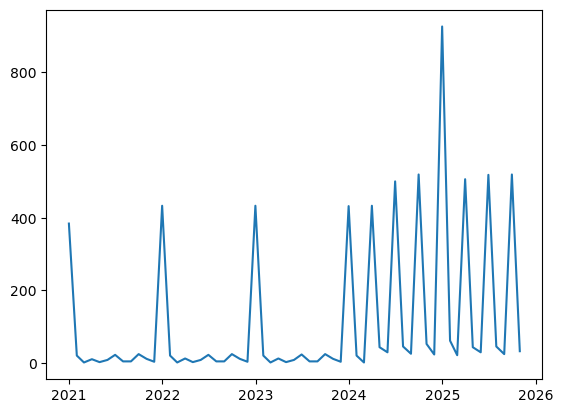

In [19]:
date_count = financials_all['date'].value_counts().reset_index().sort_values('date')
date_count['date'] = pd.to_datetime(date_count['date'])
plt.plot(date_count['date'], date_count['count'])

In [20]:
fundamentals.to_csv("data/fundamentals_signals.csv", index=False)
financials_all.to_csv("data/financials_raw.csv", index=False)